In [51]:
# loader scripts

import requests
import pandas as pd

def to_tz(df_, time_col, tz_offset, tz_name):
    return (df_
    .groupby(tz_offset)
    [time_col]
    .transform(lambda s: pd.to_datetime(s)
    .dt.tz_localize(s.name, ambiguous=True)
    .dt.tz_convert(tz_name))
    )



def load_fuel_economy_data() -> pd.DataFrame :
    url = 'https://www.fueleconomy.gov/feg/epadata/vehicles.csv'
    cols = ['year', 'make', 'model', 'trany', 'drive', 'VClass', 'eng_dscr',
            'barrels08', 'city08', 'comb08', 'range', 'evMotor', 'cylinders', 'displ', 'fuelCost08',
            'fuelType', 'highway08', 'trans_dscr','createdOn']

    raw =  pd.read_csv(url)
    autos = (raw
        .loc[:, cols]
        .assign(
            # Extract Timezone Offset (e.g., EDT -> EST5EDT)
            offset=(raw.createdOn.str.extract(r'\d\d:\d\d (?P<offset>[A-Z]{3}?)')
                    ['offset'].replace('EDT', 'EST5EDT')),
            
            # Reconstruct date string (removing the original TZ name for parsing)
            str_date=(raw.createdOn.str.slice(4, 19) + " " +
                    raw.createdOn.str.slice(-4)),
            
            # Convert to localized datetime
            createdOn=lambda df_: to_tz(df_, 'str_date', 'offset', 'America/New_York')
        )
        .drop(columns=['offset', 'str_date']) # Clean up temp columns
        )
    return autos

In [52]:
# analyzing the data
df = load_fuel_economy_data()

df.head()

C:\Users\dsgou\AppData\Local\Temp\ipykernel_38812\2720021934.py:23: DtypeWarning: Columns (69,71,72,73,74,75,77,80) have mixed types. Specify dtype option on import or set low_memory=False.
  raw =  pd.read_csv(url)


,year,make,model,trany,drive,VClass,eng_dscr,barrels08,city08,comb08,range,evMotor,cylinders,displ,fuelCost08,fuelType,highway08,trans_dscr,createdOn
0,1985,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(FFS),14.167143,19,21,0,NaN,4.0,2.0,2850,Regular,25,NaN,2013-01-01 00:00:00-05:00
1,1985,Ferrari,Testarossa,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(GUZZLER),27.046364,9,11,0,NaN,12.0,4.9,5450,Regular,14,NaN,2013-01-01 00:00:00-05:00
2,1985,Dodge,Charger,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,(FFS),11.018889,23,27,0,NaN,4.0,2.2,2200,Regular,33,SIL,2013-01-01 00:00:00-05:00
3,1985,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,Rear-Wheel Drive,Vans,NaN,27.046364,10,11,0,NaN,8.0,5.2,5450,Regular,12,NaN,2013-01-01 00:00:00-05:00
4,1993,Subaru,Legacy AWD Turbo,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,"(FFS,TRBO)",15.658421,17,19,0,NaN,4.0,2.2,3650,Premium,23,NaN,2013-01-01 00:00:00-05:00


In [3]:
df.isna().mean()*100

year           0.000000
make           0.000000
model          0.000000
trany          0.022068
drive          2.379328
VClass         0.000000
eng_dscr      36.530514
barrels08      0.000000
city08         0.000000
comb08         0.000000
range          0.000000
evMotor       93.084701
cylinders      2.951089
displ          2.947077
fuelCost08     0.000000
fuelType       0.000000
highway08      0.000000
trans_dscr    69.819043
createdOn      0.000000
dtype: float64

In [4]:
# find all vehicles that have missing cylinders info
df[df['cylinders'].isna()]

# This is likely going to be EVs where the data is expected to be missing
# To "clean" our data we will want to set this value to something meaningful
# Usually we consult SMEs to understand what would be the neutral state of the data
# when values are missing
# In this case 0 is the right answer but it could easily be mean or median depending 
# on the semantic nature of the data

,year,make,model,trany,drive,VClass,eng_dscr,barrels08,city08,comb08,range,evMotor,cylinders,displ,fuelCost08,fuelType,highway08,trans_dscr,createdOn
7138,2000,Nissan,Altra EV,NaN,NaN,Midsize Station Wagons,NaN,0.0960,81,85,90,62 KW AC Induction,NaN,NaN,900,Electricity,91,NaN,2013-01-01 00:00:00-05:00
7139,2000,Toyota,RAV4 EV,NaN,2-Wheel Drive,Sport Utility Vehicle - 2WD,NaN,0.1128,81,72,88,50 KW DC,NaN,NaN,1050,Electricity,64,NaN,2013-01-01 00:00:00-05:00
8143,2001,Toyota,RAV4 EV,NaN,2-Wheel Drive,Sport Utility Vehicle - 2WD,NaN,0.1128,81,72,88,50 KW DC,NaN,NaN,1050,Electricity,64,NaN,2013-01-01 00:00:00-05:00
8144,2001,Ford,Th!nk,NaN,NaN,Two Seaters,NaN,0.1248,74,65,29,27 KW AC Induction,NaN,NaN,1150,Electricity,58,NaN,2013-01-01 00:00:00-05:00
8146,2001,Ford,Explorer USPS Electric,NaN,2-Wheel Drive,Sport Utility Vehicle - 2WD,NaN,0.2088,45,39,38,67 KW AC Induction,NaN,NaN,1950,Electricity,33,NaN,2013-01-01 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44321,2026,Toyota,bZ Woodland AWD 235/60R18,Automatic (A1),All-Wheel Drive,Small Sport Utility Vehicle 4WD,NaN,0.0696,127,117,281,167 kW AC Synchronous,NaN,NaN,650,Electricity,107,NaN,2026-03-18 00:00:00-04:00
44322,2026,Toyota,bZ Woodland AWD 235/65R18,Automatic (A1),All-Wheel Drive,Small Sport Utility Vehicle 4WD,NaN,0.0744,117,109,260,167 kW AC Synchronous,NaN,NaN,700,Electricity,100,NaN,2026-03-18 00:00:00-04:00
44323,2026,Toyota,C-HR AWD 18inch,Automatic (A1),All-Wheel Drive,Small Sport Utility Vehicle 4WD,NaN,0.0696,127,117,287,87 and 167 kW AC Synchronous,NaN,NaN,650,Electricity,107,NaN,2026-03-18 00:00:00-04:00
44324,2026,Toyota,C-HR AWD 20inch,Automatic (A1),All-Wheel Drive,Small Sport Utility Vehicle 4WD,NaN,0.0720,122,112,273,87 and 167 kW AC Synchronous,NaN,NaN,650,Electricity,102,NaN,2026-03-18 00:00:00-04:00


In [5]:
# assign the missing values to 0
df.assign(cylinders=df.cylinders.fillna(0))

,year,make,model,trany,drive,VClass,eng_dscr,barrels08,city08,comb08,range,evMotor,cylinders,displ,fuelCost08,fuelType,highway08,trans_dscr,createdOn
0,1985,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(FFS),14.167143,19,21,0,NaN,4.0,2.0,2850,Regular,25,NaN,2013-01-01 00:00:00-05:00
1,1985,Ferrari,Testarossa,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(GUZZLER),27.046364,9,11,0,NaN,12.0,4.9,5450,Regular,14,NaN,2013-01-01 00:00:00-05:00
2,1985,Dodge,Charger,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,(FFS),11.018889,23,27,0,NaN,4.0,2.2,2200,Regular,33,SIL,2013-01-01 00:00:00-05:00
3,1985,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,Rear-Wheel Drive,Vans,NaN,27.046364,10,11,0,NaN,8.0,5.2,5450,Regular,12,NaN,2013-01-01 00:00:00-05:00
4,1993,Subaru,Legacy AWD Turbo,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,"(FFS,TRBO)",15.658421,17,19,0,NaN,4.0,2.2,3650,Premium,23,NaN,2013-01-01 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49841,1993,Subaru,Legacy,Automatic 4-spd,Front-Wheel Drive,Compact Cars,(FFS),13.523182,19,22,0,NaN,4.0,2.2,2700,Regular,26,CLKUP,2013-01-01 00:00:00-05:00
49842,1993,Subaru,Legacy,Manual 5-spd,Front-Wheel Drive,Compact Cars,(FFS),12.935217,20,23,0,NaN,4.0,2.2,2600,Regular,28,NaN,2013-01-01 00:00:00-05:00
49843,1993,Subaru,Legacy AWD,Automatic 4-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,18,21,0,NaN,4.0,2.2,2850,Regular,24,CLKUP,2013-01-01 00:00:00-05:00
49844,1993,Subaru,Legacy AWD,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,18,21,0,NaN,4.0,2.2,2850,Regular,24,NaN,2013-01-01 00:00:00-05:00


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn import set_config

# set output to pandas 
set_config(transform_output='pandas')

# create a pipeline for cylinders
cyl_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value=0)) # assign the default value to 0 for missing values
])

cyl_pipe.fit_transform(df[['cylinders']])


,cylinders
0,4.0
1,12.0
2,4.0
3,8.0
4,4.0
...,...
49841,4.0
49842,4.0
49843,4.0
49844,4.0


In [7]:
# see where it "filled" the missing values

(cyl_pipe
.fit_transform(df[['cylinders']]) # the transformed values
.loc[df.cylinders.isna()] # from the original dataframes all the na columns for cylinders
)

,cylinders
7138,0.0
7139,0.0
8143,0.0
8144,0.0
8146,0.0
...,...
44321,0.0
44322,0.0
44323,0.0
44324,0.0


In [8]:
# The prod like pipeline if we really decided to use cylinder and displacement columns

from sklearn.compose import ColumnTransformer

# create the imputers
cylinders_imputer = SimpleImputer(strategy='constant', fill_value=0) # fill missing values with 0
displ_imputer = SimpleImputer(strategy='median') # fill missing values with median


# create the preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cyl_imputer', cylinders_imputer, ['cylinders']), # creates a new columnn with the transform applied
        ('displ_imputer', displ_imputer, ['displ'])
    ],
    remainder='passthrough' # passes through all the existing columns
)

# create the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# fit and transform the data
pipeline.fit_transform(df)


,cyl_imputer__cylinders,displ_imputer__displ,remainder__year,remainder__make,remainder__model,remainder__trany,remainder__drive,remainder__VClass,remainder__eng_dscr,remainder__barrels08,remainder__city08,remainder__comb08,remainder__range,remainder__evMotor,remainder__fuelCost08,remainder__fuelType,remainder__highway08,remainder__trans_dscr,remainder__createdOn
0,4.0,2.0,1985,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(FFS),14.167143,19,21,0,NaN,2850,Regular,25,NaN,2013-01-01 00:00:00-05:00
1,12.0,4.9,1985,Ferrari,Testarossa,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(GUZZLER),27.046364,9,11,0,NaN,5450,Regular,14,NaN,2013-01-01 00:00:00-05:00
2,4.0,2.2,1985,Dodge,Charger,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,(FFS),11.018889,23,27,0,NaN,2200,Regular,33,SIL,2013-01-01 00:00:00-05:00
3,8.0,5.2,1985,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,Rear-Wheel Drive,Vans,NaN,27.046364,10,11,0,NaN,5450,Regular,12,NaN,2013-01-01 00:00:00-05:00
4,4.0,2.2,1993,Subaru,Legacy AWD Turbo,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,"(FFS,TRBO)",15.658421,17,19,0,NaN,3650,Premium,23,NaN,2013-01-01 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49841,4.0,2.2,1993,Subaru,Legacy,Automatic 4-spd,Front-Wheel Drive,Compact Cars,(FFS),13.523182,19,22,0,NaN,2700,Regular,26,CLKUP,2013-01-01 00:00:00-05:00
49842,4.0,2.2,1993,Subaru,Legacy,Manual 5-spd,Front-Wheel Drive,Compact Cars,(FFS),12.935217,20,23,0,NaN,2600,Regular,28,NaN,2013-01-01 00:00:00-05:00
49843,4.0,2.2,1993,Subaru,Legacy AWD,Automatic 4-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,18,21,0,NaN,2850,Regular,24,CLKUP,2013-01-01 00:00:00-05:00
49844,4.0,2.2,1993,Subaru,Legacy AWD,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,18,21,0,NaN,2850,Regular,24,NaN,2013-01-01 00:00:00-05:00


<Axes: >

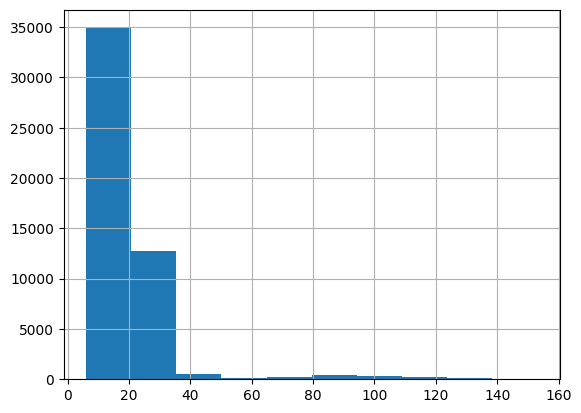

In [ ]:
import numpy as np
df.city08.hist()


<Axes: >

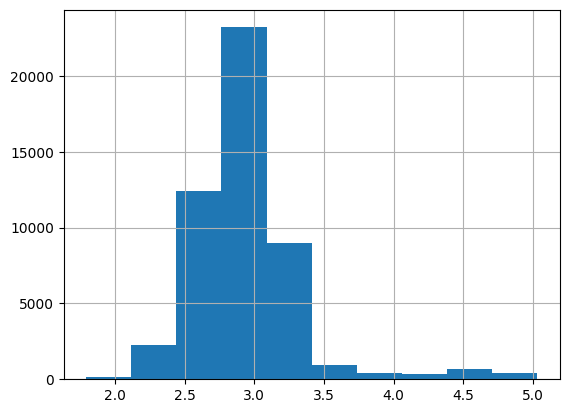

In [22]:

# log hist confirms the long tail
np.log(df.city08).hist()

((array([-4.19068501, -3.98490394, -3.8727126 , ...,  3.8727126 ,
          3.98490394,  4.19068501], shape=(49846,)),
  array([  6,   6,   6, ..., 151, 153, 153], shape=(49846,))),
 (np.float64(9.956278912254112),
  np.float64(20.762889700276848),
  np.float64(0.6709866950065867)))

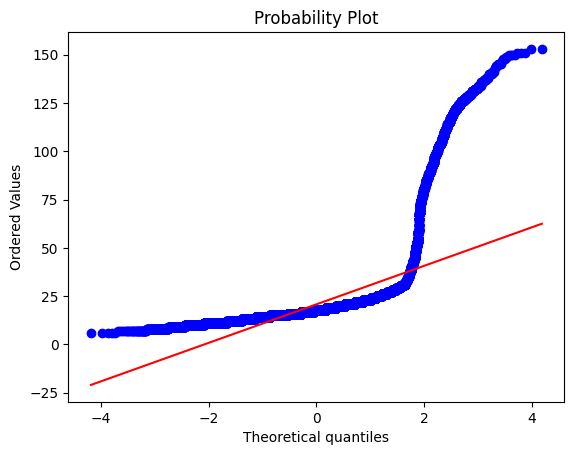

In [ ]:
from scipy import stats
from matplotlib import pyplot as plt


stats.probplot(df.city08, plot=plt)
# the overall plot doesn't align with the normal distribution straight line

((array([-4.18162241, -3.97541764, -3.86297892, ...,  3.86297892,
          3.97541764,  4.18162241], shape=(47896,)),
  array([ 6,  6,  6, ..., 39, 39, 39], shape=(47896,))),
 (np.float64(4.599703021358447),
  np.float64(18.16130783363955),
  np.float64(0.9783913908420713)))

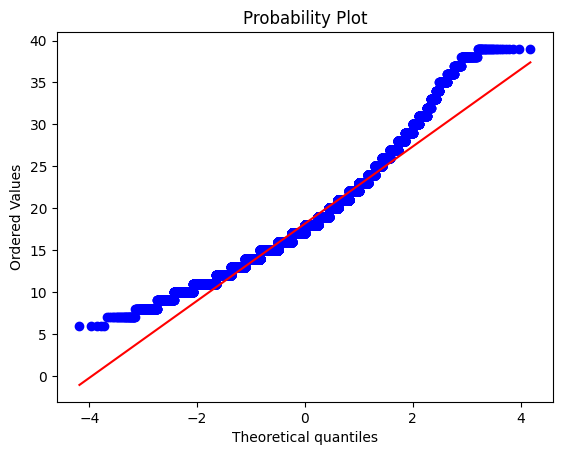

In [ ]:
stats.probplot(df[df['city08']<40].city08, plot=plt)
# the filtered subset does a much better job of aligning

c:\repos\ai-portfolio\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


<Axes: xlabel='binning__city08'>

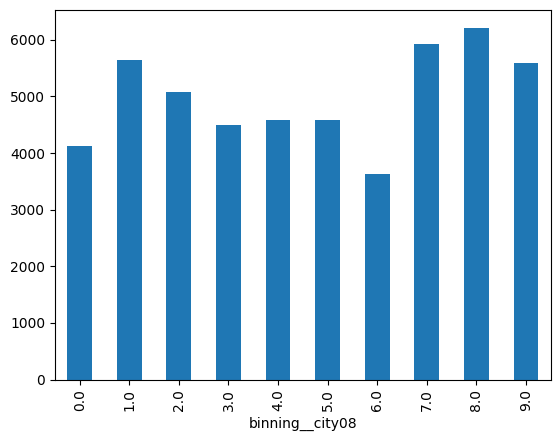

In [ ]:
# There are a few ways we could handle this skewed data

# 1. ignore the skewed tail as noisy outliers but this is risky what if the tail is actually a strong signal
# like luxury/sports vehicles with low mileage, model should work against them too

# 2. Bin the data so we can address the normal distribution shaped data
# if we use equally spaced bins like below we won't get a normal distribution over bins

from sklearn.preprocessing import KBinsDiscretizer

column_transformer = ColumnTransformer(
    transformers = [
        ('binning', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), ['city08'])
    ],
    remainder = 'passthrough'
)

pipeline = Pipeline(steps=[('transformer', column_transformer)])
pipeline.fit_transform(df).binning__city08.value_counts().sort_index().plot.bar()


In [ ]:
cylinders_imputer = SimpleImputer(strategy='constant', fill_value=0)
displ_imputer = SimpleImputer(strategy='median')
binning_strategy = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

column_transformer = ColumnTransformer(
    transformers = [
        ('cyl_imputer', cylinders_imputer, ['cylinders']), # creates a new columnn with the transform applied
        ('displ_imputer', displ_imputer, ['displ']),
        ('binning', binning_strategy, ['city08'])
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[('transformer', column_transformer)])
pipeline.fit_transform(df)

# Transforms, binning or other strategies are a judgement call, tune as needed, a lot of the times
# linear regression works well without this tuning

c:\repos\ai-portfolio\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,cyl_imputer__cylinders,displ_imputer__displ,binning__city08,remainder__year,remainder__make,remainder__model,remainder__trany,remainder__drive,remainder__VClass,remainder__eng_dscr,remainder__barrels08,remainder__comb08,remainder__range,remainder__evMotor,remainder__fuelCost08,remainder__fuelType,remainder__highway08,remainder__trans_dscr,remainder__createdOn
0,4.0,2.0,3.0,1985,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(FFS),14.167143,21,0,NaN,2850,Regular,25,NaN,2013-01-01 00:00:00-05:00
1,12.0,4.9,0.0,1985,Ferrari,Testarossa,Manual 5-spd,Rear-Wheel Drive,Two Seaters,(GUZZLER),27.046364,11,0,NaN,5450,Regular,14,NaN,2013-01-01 00:00:00-05:00
2,4.0,2.2,4.0,1985,Dodge,Charger,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,(FFS),11.018889,27,0,NaN,2200,Regular,33,SIL,2013-01-01 00:00:00-05:00
3,8.0,5.2,0.0,1985,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,Rear-Wheel Drive,Vans,NaN,27.046364,11,0,NaN,5450,Regular,12,NaN,2013-01-01 00:00:00-05:00
4,4.0,2.2,2.0,1993,Subaru,Legacy AWD Turbo,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,"(FFS,TRBO)",15.658421,19,0,NaN,3650,Premium,23,NaN,2013-01-01 00:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49841,4.0,2.2,3.0,1993,Subaru,Legacy,Automatic 4-spd,Front-Wheel Drive,Compact Cars,(FFS),13.523182,22,0,NaN,2700,Regular,26,CLKUP,2013-01-01 00:00:00-05:00
49842,4.0,2.2,3.0,1993,Subaru,Legacy,Manual 5-spd,Front-Wheel Drive,Compact Cars,(FFS),12.935217,23,0,NaN,2600,Regular,28,NaN,2013-01-01 00:00:00-05:00
49843,4.0,2.2,2.0,1993,Subaru,Legacy AWD,Automatic 4-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,21,0,NaN,2850,Regular,24,CLKUP,2013-01-01 00:00:00-05:00
49844,4.0,2.2,2.0,1993,Subaru,Legacy AWD,Manual 5-spd,4-Wheel or All-Wheel Drive,Compact Cars,(FFS),14.167143,21,0,NaN,2850,Regular,24,NaN,2013-01-01 00:00:00-05:00


<Axes: xlabel='city08_log', ylabel='city08'>

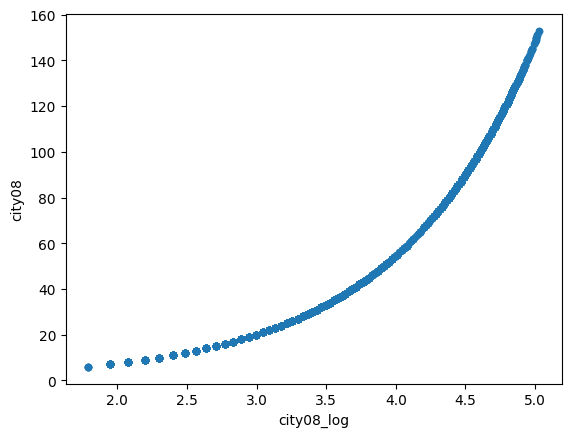

In [24]:
# check how the log of the values behave wrt the original values
(
df
.assign(city08_log=np.log(df.city08))
.plot.scatter(x='city08_log', y='city08')
)

<Axes: >

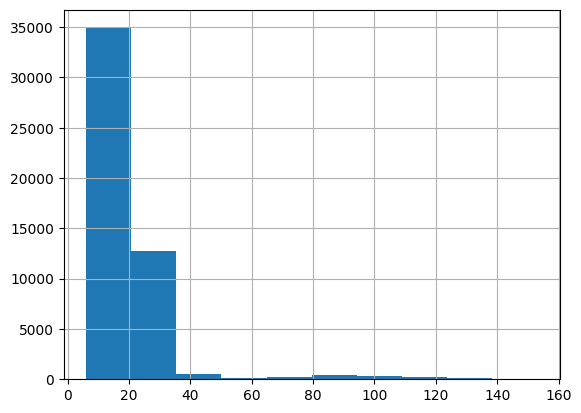

In [ ]:

# also check the hist to see the distribution of values
df.city08.hist()

<Axes: >

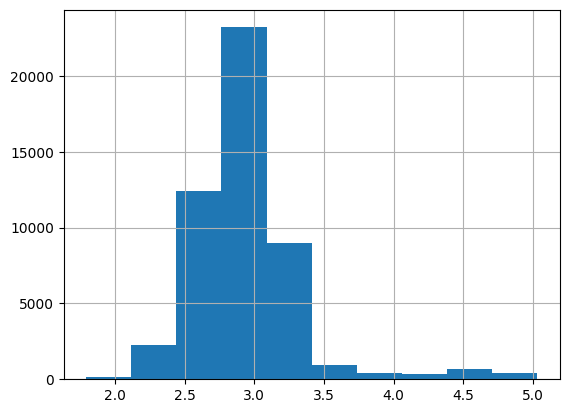

In [26]:
np.log(df.city08).hist()

In [30]:
# Build a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df.drop(columns=['city08', 'highway08', 'comb08']).select_dtypes('number')
y=df.city08

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

cylinders_imputer = SimpleImputer(strategy='constant', fill_value=0)
displ_imputer = SimpleImputer(strategy='median')

column_transformer = ColumnTransformer(
    transformers = [
        ('cyl_imputer', cylinders_imputer, ['cylinders']), # creates a new columnn with the transform applied
        ('displ_imputer', displ_imputer, ['displ'])
    ],
    remainder='passthrough'
)

# train the model
pipeline = Pipeline(steps=[('preprocessor', column_transformer), ('lr', LinearRegression())])
pipeline.fit(X_train, y_train)


# evaluate the model
pipeline.score(X_test, y_test) # r2 score 



0.7811721690912162

In [29]:
from sklearn.metrics import mean_absolute_error
# MSE
mean_absolute_error(y_test, pipeline.predict(X_test))

3.994584436067657

In [31]:
# use log transform to model now
y_log=np.log(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, random_state=42)

pipeline_log = Pipeline(steps=[('transformer', column_transformer), ('lr', LinearRegression())])
pipeline_log.fit(X_train, y_train)

print(f"R2 score is {pipeline_log.score(X_test, y_test)}")
print(f"mse is {mean_absolute_error(y_test, pipeline_log.predict(X_test))}")

R2 score is 0.9081680029292881
mse is 0.07678402123198645


<Axes: xlabel='barrels08_log', ylabel='city08'>

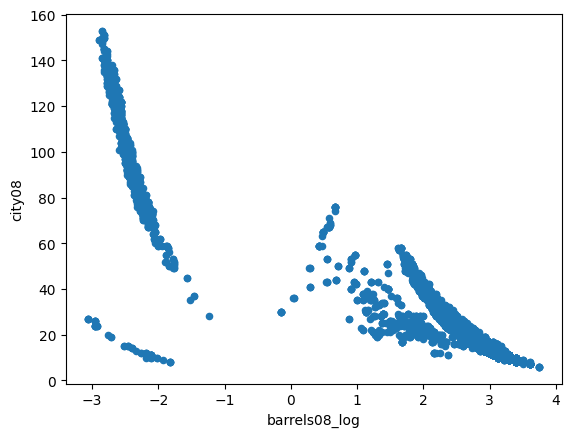

In [42]:
(
df
.assign(barrels08_log=np.log(df.barrels08))
.plot.scatter(x='barrels08_log', y='city08')
)

<Axes: >

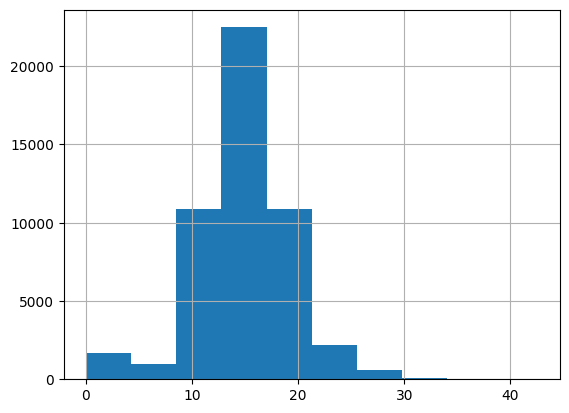

In [35]:
df.barrels08.hist()


In [36]:
df.barrels08.isna().sum()

np.int64(0)

In [41]:
# Build a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[['barrels08']]
y=df.city08

X_train, X_test, y_train, y_test = train_test_split(X, np.log(y), random_state=42)


# train the model
pipeline = Pipeline(steps=[('lr', LinearRegression())])
pipeline.fit(X_train, y_train)


# evaluate the model

print(f"R2 score is {pipeline.score(X_test, y_test)}")
print(f"mse is {mean_absolute_error(y_test, pipeline.predict(X_test))}")


R2 score is 0.8587096406766863
mse is 0.08788183430810241


In [56]:
# we can see that barrels are strictly 0 for some class of vehicles meaning they might just be EVs
# so let's add that as a feature

# Build a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[df['barrels08']>0][['barrels08']]
y=df[df['barrels08']>0].city08

X_train, X_test, y_train, y_test = train_test_split(X, np.log(y), random_state=42)


# train the model
pipeline = Pipeline(steps=[('lr', LinearRegression())])
pipeline.fit(X_train, y_train)


# evaluate the model

print(f"R2 score is {pipeline.score(X_test, y_test)}")
print(f"mse is {mean_absolute_error(y_test, pipeline.predict(X_test))}")


R2 score is 0.8587096406766863
mse is 0.08788183430810241


In [45]:
X_train.head

<bound method NDFrame.head of        barrels08  is_ev
44707  22.885385      1
27296  10.258966      1
13095  15.658421      1
48291  11.900400      1
11146  12.396250      1
...          ...    ...
11284  19.834000      1
44732  11.442692      1
38158  16.528333      1
860    14.875500      1
15795  11.018889      1

[37384 rows x 2 columns]>